## Interkulturelle Vergleichsanalyse mit der World Values Survey (WVS)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Daten einlesen
df = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", sep = ",")

/var/folders/v6/9c6hcq397n90s3n8znn3v7vh0000gn/T/ipykernel_22937/1619012253.py:2: DtypeWarning: Columns (0: X002_02B, 1: V002A_01, 2: V001A_01, 3: Partyname, 4: Partyabb, 5: CPARTY, 6: CPARTYABB) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", sep = ",")


## Auswahl von Ländern und Merkmalen
- Nigeria: 566
- Phillipinen: 608
- Mexiko: 484
- Deutschland: 276
- Indien: 356

In [3]:
laender = [566, 608, 484, 276, 356]
df_country = df[df["B_COUNTRY"].isin(laender)]
df_country.head()

,version,doi,A_WAVE,A_YEAR,A_STUDY,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,D_INTERVIEW,...,WVS_Polmistrust_PartyVoter,WVS_LR_MedianVoter,WVS_LibCon_MedianVoter,v2psbars,v2psorgs,v2psprbrch,v2psprlnks,v2psplats,v2xnp_client,v2xps_party
21846,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070001,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21847,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21848,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070003,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21849,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070004,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21850,6-0-0 (2024-04-30),doi.org/10.14281/18241.24,7,2018,2,276,DEU,255,GMY,276070005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_country["B_COUNTRY_ALPHA"].value_counts()

B_COUNTRY_ALPHA
MEX    1741
IND    1692
DEU    1528
NGA    1237
PHL    1200
Name: count, dtype: int64

## Merkmale zu Indikatoren zusammenfassen

In [5]:
fragen = ['Q32', 'Q33', 'Q28', 'Q235', 'Q71', 'Q43', 'Q150', 'Q48', 'Q149']


# Nur relevante Spalten + Ländervariable behalten
df_merkm = df_country[["B_COUNTRY_ALPHA"] + fragen].copy()
df_merkm["W_WEIGHT"] = df["W_WEIGHT"]

## Mittelkategorie entfernen und binäre Spalte erstellen

In [6]:
def binary_split(df, col, skala=4):
    """
    Teilt eine Likert-Skala (1 bis `skala`) binär in Zustimmung/Ablehnung.
    Neutrale Mittelkategorien (bei ungeraden Skalen) werden der Ablehnungsseite
    zugeschlagen, um die Vergleichbarkeit zwischen Ländern nicht zu verzerren.
    """
    df_merkm = df.copy()
    df_merkm = df_merkm[df_merkm[col] > 0]  # nur echte Missings (negative Codes) raus

    mitte = skala / 2

    df_merkm[f'{col}_binary'] = df_merkm[col].apply(
        lambda x: 'Zustimmung' if x <= mitte else 'Ablehnung'
    )
    return df_merkm

In [7]:
# ── Indikator 1: Arbeit ──
df_merkm = binary_split(df_merkm, 'Q28', skala=4)
df_merkm = binary_split(df_merkm, 'Q32', skala=4)
df_merkm = binary_split(df_merkm, 'Q33', skala=5)

# ── Indikator 2: Führung ──
df_merkm = binary_split(df_merkm, 'Q235', skala=4)
df_merkm = binary_split(df_merkm, 'Q71', skala=4)

# ── Indikator 3: Freiheit ──
df_merkm = binary_split(df_merkm, 'Q43', skala=3)
df_merkm = binary_split(df_merkm, 'Q48', skala=10)
df_merkm = binary_split(df_merkm, 'Q149', skala=2)
df_merkm = binary_split(df_merkm, 'Q150',  skala=2)

## Erstellung der Tabellen für den Bericht

In [15]:
# ── Item Labels ──
item_labels = {
    'Q32': 'Hausfrau erfüllend',
    'Q33': 'Männer Recht auf Arbeitsplatz',
    'Q28': 'Vorschulkind leidet',
    'Q235': 'Starker Führer',
    'Q71': 'Hörigkeit Kinder',
    'Q43': 'Arbeit verliert Bedeutung',
    'Q150': 'Freiheit vs. Sicherheit',
    'Q48': 'Entscheidungsfreiheit',
    'Q149': 'Freiheit vs. Gleichheit'
}

# ── Einzelne Items pro Indikator ──
indikatoren_dict = {
    'Arbeit':    ['Q32', 'Q33', 'Q28'],
    'Führung':   ['Q235', 'Q71'],
    'Freiheit':  ['Q43', 'Q150', 'Q48', 'Q149']
}

In [16]:
for indikator, item_list in indikatoren_dict.items():
    rows = []
    for item in item_list:
        col = f'{item}_binary'

        # Gewichtete Summe pro Land
        result = df_merkm.groupby(['B_COUNTRY_ALPHA', col])['W_WEIGHT'].sum().unstack(fill_value=0)
        result_pct = result.div(result.sum(axis=1), axis=0) * 100

        zust_col = [c for c in result_pct.columns if str(c) in ['Zustimmung', '1', 'agree', 'True']][0]
        zustimmung = result_pct[zust_col].round(1).reset_index()
        zustimmung['Item'] = item_labels[item]
        zustimmung = zustimmung.rename(columns={zust_col: 'Zustimmung'})

        # Gewichtete Summe über alle Länder hinweg (TOTAL)
        result_total = df_merkm.groupby(col)['W_WEIGHT'].sum()
        result_total_pct = result_total / result_total.sum() * 100
        total_wert = result_total_pct.get(zust_col, np.nan).round(1)

        total_row = pd.DataFrame({
            'B_COUNTRY_ALPHA': ['TOTAL'],
            'Zustimmung': [total_wert],
            'Item': [item_labels[item]]
        })

        rows.append(pd.concat([zustimmung, total_row], ignore_index=True))

    df_result = pd.concat(rows)
    df_pivot = df_result.pivot_table(index='Item',
                                     columns='B_COUNTRY_ALPHA',
                                     values='Zustimmung')

    # TOTAL-Spalte ans Ende sortieren
    cols = [c for c in df_pivot.columns if c != 'TOTAL'] + ['TOTAL']
    df_pivot = df_pivot[cols]

    # Werte als String mit Prozentzeichen formatieren
    df_pivot_str = df_pivot.map(lambda x: f'{x:.2f}\\%')
    latex = df_pivot_str.to_latex(
        caption=f'Zustimmung (\\%): {indikator}',
        label=f'tab:zustimmung_{indikator.lower()}',
        column_format='l' + 'r' * len(df_pivot_str.columns),
        escape=False
    )
    latex = latex.replace('\\begin{tabular}',
                          '% Benötigt: \\usepackage{booktabs}\n\\begin{tabular}')
    print(latex)
    print('\n\n')

\begin{table}
\caption{Zustimmung (\%): Arbeit}
\label{tab:zustimmung_arbeit}
% Benötigt: \usepackage{booktabs}
\begin{tabular}{lrrrrrr}
\toprule
B_COUNTRY_ALPHA & DEU & IND & MEX & NGA & PHL & TOTAL \\
Item &  &  &  &  &  &  \\
\midrule
Hausfrau erfüllend & 59.10\% & 56.50\% & 57.50\% & 38.70\% & 84.30\% & 59.10\% \\
Männer Recht auf Arbeitsplatz & 9.80\% & 59.40\% & 24.90\% & 65.60\% & 69.10\% & 44.60\% \\
Vorschulkind leidet & 30.00\% & 72.20\% & 52.80\% & 41.30\% & 46.40\% & 49.50\% \\
\bottomrule
\end{tabular}
\end{table}




\begin{table}
\caption{Zustimmung (\%): Führung}
\label{tab:zustimmung_führung}
% Benötigt: \usepackage{booktabs}
\begin{tabular}{lrrrrrr}
\toprule
B_COUNTRY_ALPHA & DEU & IND & MEX & NGA & PHL & TOTAL \\
Item &  &  &  &  &  &  \\
\midrule
Hörigkeit Kinder & 45.80\% & 67.50\% & 17.60\% & 40.20\% & 81.80\% & 48.80\% \\
Starker Führer & 26.70\% & 68.50\% & 71.30\% & 60.40\% & 75.30\% & 61.30\% \\
\bottomrule
\end{tabular}
\end{table}




\begin{table}
\caption{

## Balkendiagramme zu den Indikatoren

In [18]:
laender = ['DEU', 'IND', 'MEX', 'NGA', 'PHL']
farben = ['#1a1a1a', '#FF9933', '#CE1126', '#006847', '#0038A8']

def gewichteter_anteil_zustimmung(df, col, land_col='B_COUNTRY_ALPHA', weight_col='W_WEIGHT'):
    """Gibt für jedes Land den gewichteten Zustimmungsanteil (%) für ein Item zurück."""
    binary_col = f'{col}_binary'

    if binary_col not in df.columns:
        raise KeyError(f"Spalte '{binary_col}' fehlt – wurde binary_split für '{col}' aufgerufen?")

    gewichtete_summe = df.groupby([land_col, binary_col])[weight_col].sum().unstack(fill_value=0)
    anteil = gewichtete_summe.div(gewichtete_summe.sum(axis=1), axis=0) * 100

    if 'Zustimmung' not in anteil.columns:
        return pd.Series(np.nan, index=anteil.index)

    return anteil['Zustimmung']

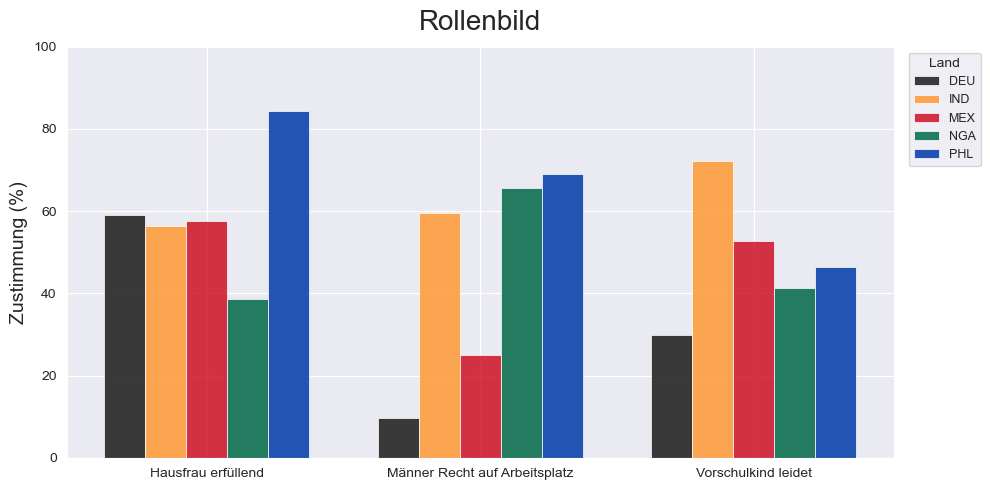

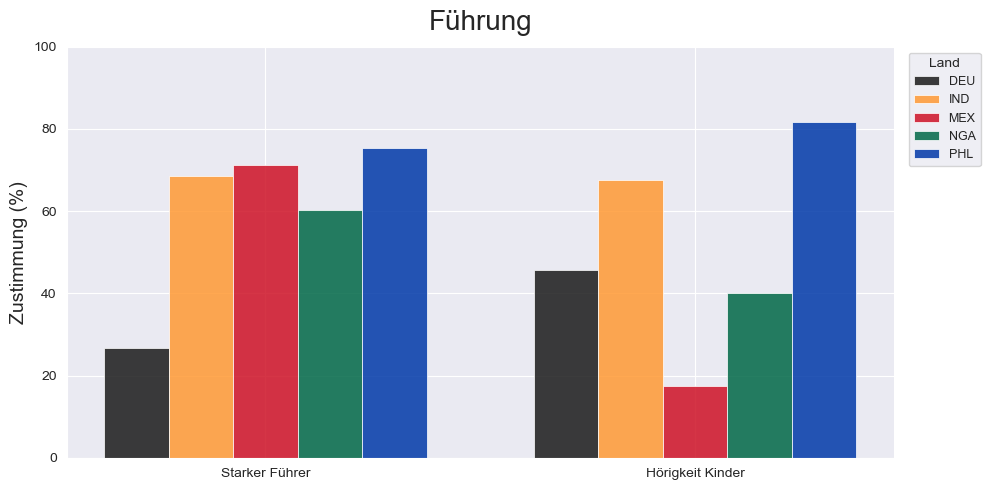

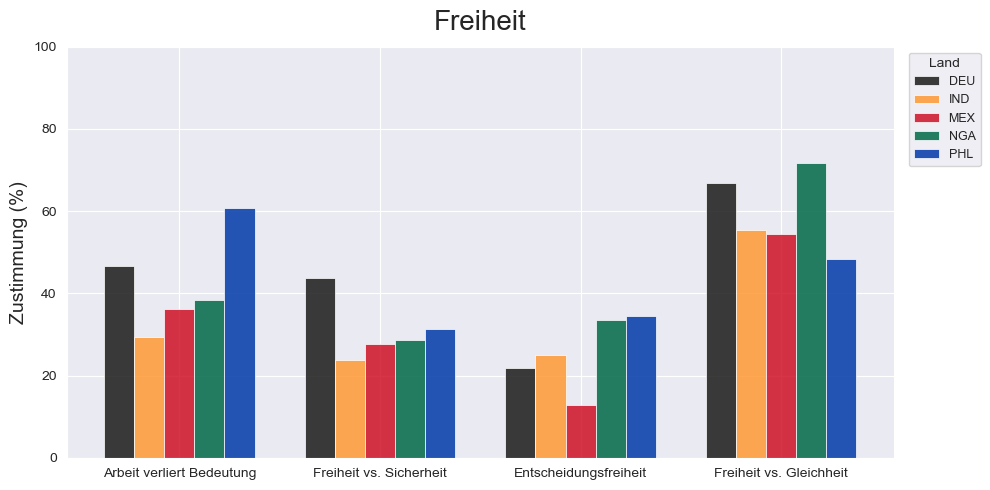

In [19]:
for indikator, item_list in items.items():

    fig, ax = plt.subplots(figsize=(10, 5))

    werte_pro_item = pd.DataFrame({
        item: gewichteter_anteil_zustimmung(df_merkm, item)
        for item in item_list
    })

    x = np.arange(len(item_list))
    n = len(laender)
    width = 0.15
    offsets = np.linspace(-(n-1)/2 * width, (n-1)/2 * width, n)

    for land, offset, farbe in zip(laender, offsets, farben):
        werte = werte_pro_item.loc[land, item_list].values
        ax.bar(x + offset, werte, width=width,
               label=land, color=farbe, alpha=0.85,
               edgecolor='white', linewidth=0.6)

    ax.set_title(indikator, fontsize=20, pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels([item_labels[i] for i in item_list], fontsize=10)
    ax.set_ylabel('Zustimmung (%)', fontsize=14)
    ax.set_ylim(0, 100)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title='Land', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

    plt.tight_layout()

    dateiname = f"items_{indikator.replace(' ', '_').replace('&', 'und')}.png"
    plt.savefig(dateiname, dpi=300, bbox_inches='tight')
    plt.show()